# 配套实践 06-02：坐标变换与误差敏感性

本练习对应基础篇第 06 章。我们把杯子点云从相机坐标变到机器人基座坐标，验证逆变换，再比较深度噪声、外参平移误差和外参旋转误差。依赖：NumPy、Matplotlib；CPU 即可运行。

<a href="https://qi-robotics.github.io/robot-world-model-tutorial/basics/06-spatial-geometry/" target="_blank">返回课程正文</a>

In [1]:
import numpy as np  # 构造刚体变换并进行误差模拟
import matplotlib.pyplot as plt  # 比较真实位置和带误差位置
np.random.seed(11)  # 固定噪声样本便于复现实验
plt.rcParams["figure.dpi"] = 120  # 提高笔记本图像清晰度

## 1. 构造合法的相机到基座变换

变量名 `transform_base_camera` 表示 $^{B}T_C$：输入相机坐标，输出基座坐标。

In [2]:
def rotation_z(angle_radian):  # 创建绕 z 轴旋转的三乘三矩阵
    cosine = np.cos(angle_radian)  # 计算给定角度的余弦
    sine = np.sin(angle_radian)  # 计算给定角度的正弦
    return np.array([[cosine, -sine, 0.0], [sine, cosine, 0.0], [0.0, 0.0, 1.0]])  # 返回右手系旋转矩阵
def make_transform(rotation, translation):  # 把旋转和平移组合为齐次变换
    transform = np.eye(4, dtype=np.float64)  # 从四乘四单位矩阵开始
    transform[:3, :3] = rotation  # 写入左上角旋转矩阵
    transform[:3, 3] = translation  # 写入目标坐标系表达的平移
    return transform  # 返回完整四乘四刚体变换
rotation_base_camera = rotation_z(np.deg2rad(28.0))  # 定义相机轴相对基座轴的旋转
translation_base_camera = np.array([0.42, -0.16, 0.72])  # 定义相机原点在基座中的位置
transform_base_camera = make_transform(rotation_base_camera, translation_base_camera)  # 形成相机到基座外参
assert np.allclose(rotation_base_camera.T @ rotation_base_camera, np.eye(3))  # 检查旋转矩阵正交
assert np.isclose(np.linalg.det(rotation_base_camera), 1.0)  # 检查旋转矩阵行列式为一

## 2. 变换点云并用逆变换检查方向

我们用一小簇点模拟相机看到的杯子表面。齐次坐标最后一维取 1，因此平移会作用于点。

In [3]:
def transform_points(transform_target_source, points_source):  # 批量把 N×3 点云变到目标坐标系
    ones = np.ones((len(points_source), 1), dtype=np.float64)  # 为每个位置点准备齐次分量一
    points_h = np.concatenate([points_source, ones], axis=1)  # 把 N×3 点云扩展成 N×4 齐次点
    transformed_h = (transform_target_source @ points_h.T).T  # 左乘变换并恢复按行存点的布局
    return transformed_h[:, :3]  # 移除齐次分量并返回目标坐标点云
angles = np.linspace(0.0, 2.0 * np.pi, 80, endpoint=False)  # 为圆形杯沿生成均匀角度
points_camera = np.stack([0.10 + 0.035 * np.cos(angles), 0.02 + 0.035 * np.sin(angles), np.full_like(angles, 0.76)], axis=1)  # 构造相机坐标中的杯沿点云
points_base = transform_points(transform_base_camera, points_camera)  # 使用真实外参变换到基座坐标
transform_camera_base = np.linalg.inv(transform_base_camera)  # 求出方向相反的基座到相机变换
points_recovered = transform_points(transform_camera_base, points_base)  # 把基座点云变回相机坐标
round_trip_error = np.linalg.norm(points_recovered - points_camera, axis=1)  # 计算往返变换误差
assert round_trip_error.max() < 1e-12  # 验证变换方向和齐次实现正确
print(f"往返变换最大误差: {round_trip_error.max():.3e} m")  # 报告浮点计算造成的极小误差
print(f"杯沿中心（基座坐标）: {points_base.mean(axis=0).round(4)} m")  # 报告控制端使用的目标中心

往返变换最大误差: 9.714e-17 m
杯沿中心（基座坐标）: [ 0.4989 -0.0954  1.48  ] m


**怎样理解上一结果：** 往返误差接近 $10^{-16}$ 米，只反映矩阵求逆和点变换实现彼此一致，不代表外参来自正确标定。杯沿中心已经使用基座坐标表达，后续规划器必须继续沿用这一坐标约定。

## 3. 分别加入三种误差

随机深度噪声逐点变化；外参平移与旋转偏差则系统性作用于整组点。这里保持每次只改变一个因素。

In [4]:
depth_noise = np.random.normal(loc=0.0, scale=0.008, size=(len(points_camera), 1))  # 模拟八毫米标准差的深度噪声
points_camera_depth_noisy = points_camera.copy()  # 复制真实相机点云避免原地修改
points_camera_depth_noisy[:, 2:3] += depth_noise  # 只扰动相机 z 深度以隔离噪声来源
points_base_depth_noisy = transform_points(transform_base_camera, points_camera_depth_noisy)  # 把带深度噪声的点变到基座
translation_bias = translation_base_camera + np.array([0.012, -0.006, 0.0])  # 为外参加入固定平移偏差
transform_translation_biased = make_transform(rotation_base_camera, translation_bias)  # 构造平移有偏的外参
points_base_translation_biased = transform_points(transform_translation_biased, points_camera)  # 计算平移偏差下的基座点云
rotation_bias = rotation_z(np.deg2rad(2.0)) @ rotation_base_camera  # 为外参加入两度系统旋转偏差
transform_rotation_biased = make_transform(rotation_bias, translation_base_camera)  # 构造旋转有偏的外参
points_base_rotation_biased = transform_points(transform_rotation_biased, points_camera)  # 计算旋转偏差下的基座点云
true_center = points_base.mean(axis=0)  # 计算真实外参下的杯沿中心
depth_center = points_base_depth_noisy.mean(axis=0)  # 计算深度噪声下的估计中心
translation_center = points_base_translation_biased.mean(axis=0)  # 计算平移偏差下的估计中心
rotation_center = points_base_rotation_biased.mean(axis=0)  # 计算旋转偏差下的估计中心
errors_mm = 1000.0 * np.array([np.linalg.norm(depth_center - true_center), np.linalg.norm(translation_center - true_center), np.linalg.norm(rotation_center - true_center)])  # 把三种中心误差换算成毫米
print(dict(zip(["深度噪声", "外参平移偏差", "外参旋转偏差"], errors_mm.round(2))))  # 报告三种误差对目标中心的影响
assert np.isfinite(errors_mm).all()  # 检查误差计算没有无效数值

{'深度噪声': 0.09, '外参平移偏差': 13.42, '外参旋转偏差': 3.56}


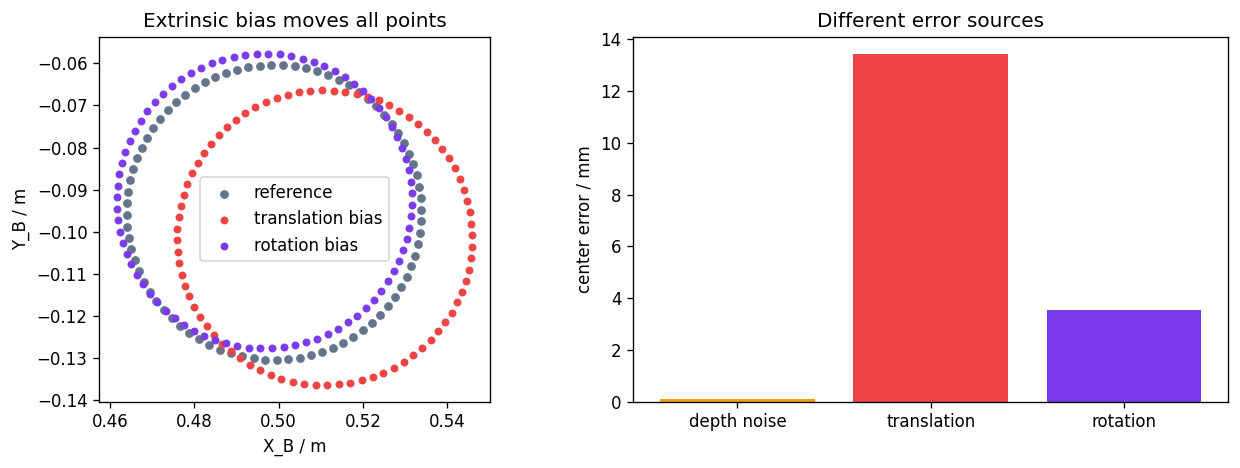

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))  # 创建点云俯视图和误差柱状图
axes[0].scatter(points_base[:, 0], points_base[:, 1], s=18, color="#64748b", label="reference")  # 绘制真实基座坐标杯沿
axes[0].scatter(points_base_translation_biased[:, 0], points_base_translation_biased[:, 1], s=14, color="#ef4444", label="translation bias")  # 绘制整体平移后的点云
axes[0].scatter(points_base_rotation_biased[:, 0], points_base_rotation_biased[:, 1], s=14, color="#7c3aed", label="rotation bias")  # 绘制整体旋转后的点云
axes[0].set_aspect("equal")  # 保持两个空间轴使用相同比例
axes[0].set_xlabel("X_B / m")  # 标注基座水平轴与单位
axes[0].set_ylabel("Y_B / m")  # 标注基座侧向轴与单位
axes[0].set_title("Extrinsic bias moves all points")  # 概括左图观察结果
axes[0].legend()  # 解释三组点云颜色
labels = ["depth noise", "translation", "rotation"]  # 准备误差柱状图标签
axes[1].bar(labels, errors_mm, color=["#f59e0b", "#ef4444", "#7c3aed"])  # 比较目标中心的毫米误差
axes[1].set_ylabel("center error / mm")  # 标注最终控制相关误差单位
axes[1].set_title("Different error sources")  # 概括右图诊断目的
plt.tight_layout()  # 调整子图和标签间距
plt.show()  # 显示误差模式与大小

**怎样理解结果：** 本次随机深度噪声对杯沿中心的影响很小，是因为正负噪声在多个点上部分抵消；约 13 毫米的外参平移偏差会整体移动全部点，取平均也无法消除。左图用于识别系统性位移模式，右图才把误差换算成与抓取精度可比较的毫米数值。

## 结论与练习

随机深度噪声会让点沿视线散开，多个点取平均后中心误差可能减小；错误外参则会一致地移动整组点，平均不能消除系统偏差。尝试把杯子深度从 0.76 米改为 1.5 米，比较同样两度旋转误差造成的位置偏差。